# MC 04 — Peak-Risk Model Comparison

Compare all Peak-Risk candidates under the common 0.50 comparison threshold and threshold-free PR-AUC.

In [1]:

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "model_comparison.yaml"


In [2]:
import matplotlib.pyplot as plt
from src.ontario_peak_risk.model_comparison.io import load_config, load_model_reports
from src.ontario_peak_risk.model_comparison.metrics import (
    peak_global_table,
    combine_group_metrics,
)
from src.ontario_peak_risk.model_comparison.plotting import (
    peak_global_plot,
    calibration_comparison_plot,
    metric_by_fold_plot,
    metric_by_horizon_plot,
    fsa_heatmap,
)

config, project_root = load_config(CONFIG_PATH)
reports = load_model_reports(config, project_root, "peak_risk")

global_table = peak_global_table(reports)
fold_table = combine_group_metrics(reports, "fold_metrics")
fsa_table = combine_group_metrics(reports, "fsa_metrics")
horizon_table = combine_group_metrics(reports, "horizon_metrics")

display(global_table.sort_values("pr_auc", ascending=False))


,model_key,model,family,precision,recall,f1,pr_auc,roc_auc,balanced_accuracy,brier_score,positive_rate_pct,predicted_positive_rate_pct,n_observations
0,logistic_regression,Logistic Regression,Baseline,0.843267,0.306492,0.449581,0.675276,0.943635,0.650943,NaN,7.482544,NaN,2519424
1,hist_gradient_boosting,HistGradientBoosting,Gradient Boosting,0.822794,0.207605,0.331553,0.579909,0.908734,0.601994,NaN,7.482544,NaN,2519424
2,random_forest,Random Forest Classifier,Bagging,0.669067,0.355315,0.464143,0.579137,0.941053,0.670551,0.044640,7.482544,3.973686,2519424
3,xgboost,XGBoost Classifier,Gradient Boosting,0.596330,0.459057,0.518766,0.556495,0.917580,0.716962,0.050577,7.482544,5.760086,2519424
4,lightgbm,LightGBM Classifier,Gradient Boosting,0.555288,0.470382,0.509321,0.532379,0.909176,0.719957,0.053348,7.482544,6.338433,2519424


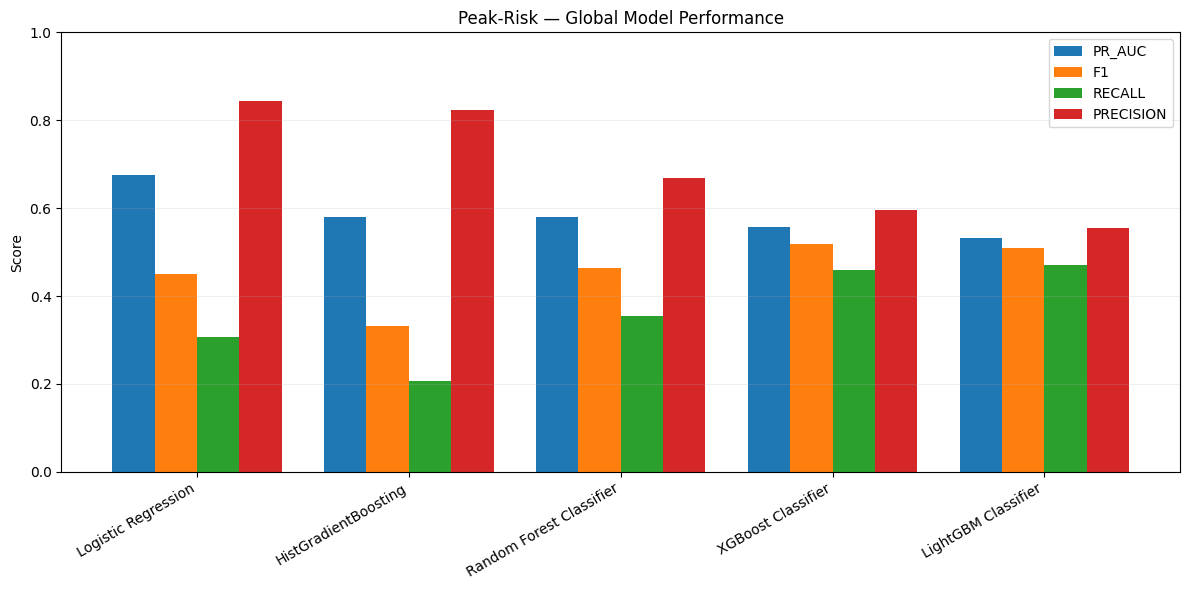

In [3]:
peak_global_plot(global_table); plt.show()

e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\model_comparison\plotting.py:276: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


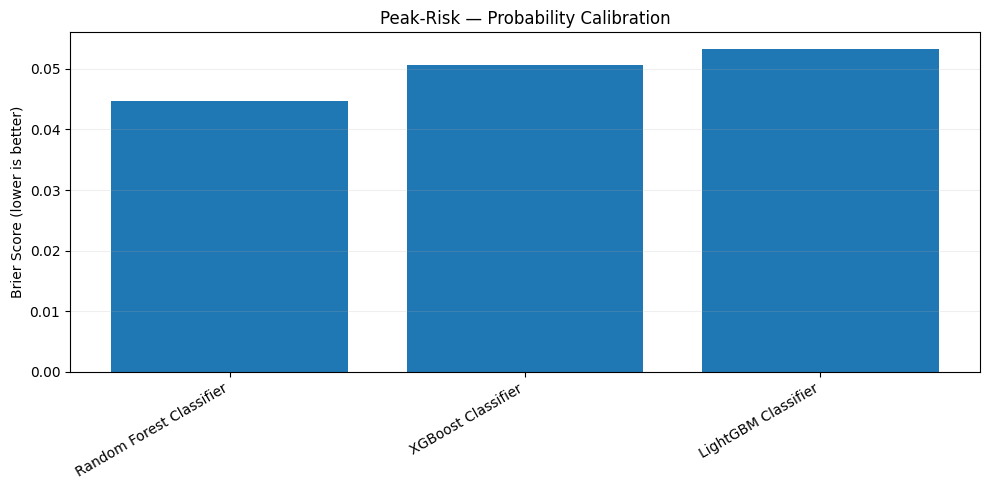

In [4]:
calibration_comparison_plot(global_table); plt.show()

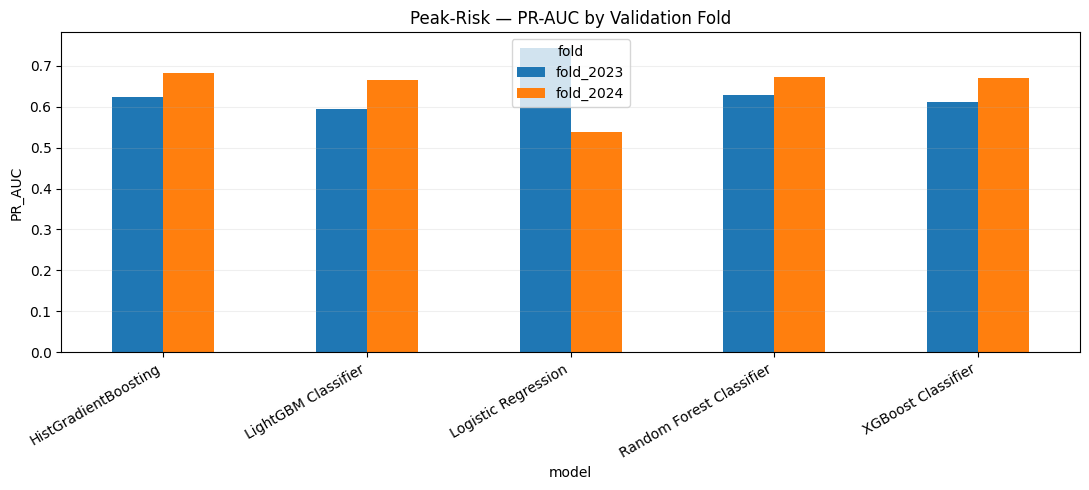

In [5]:
metric_by_fold_plot(fold_table, "pr_auc", "Peak-Risk — PR-AUC by Validation Fold"); plt.show()

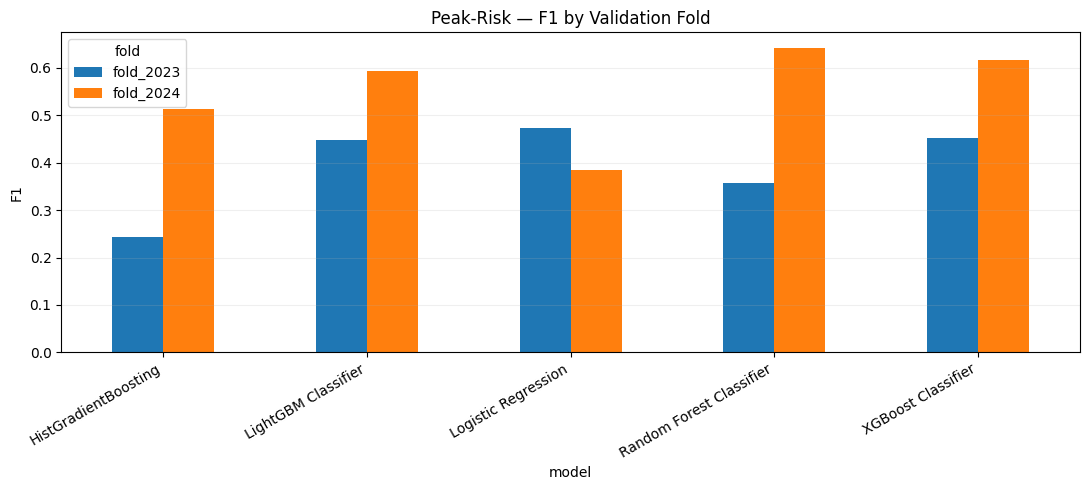

In [6]:
metric_by_fold_plot(fold_table, "f1", "Peak-Risk — F1 by Validation Fold"); plt.show()

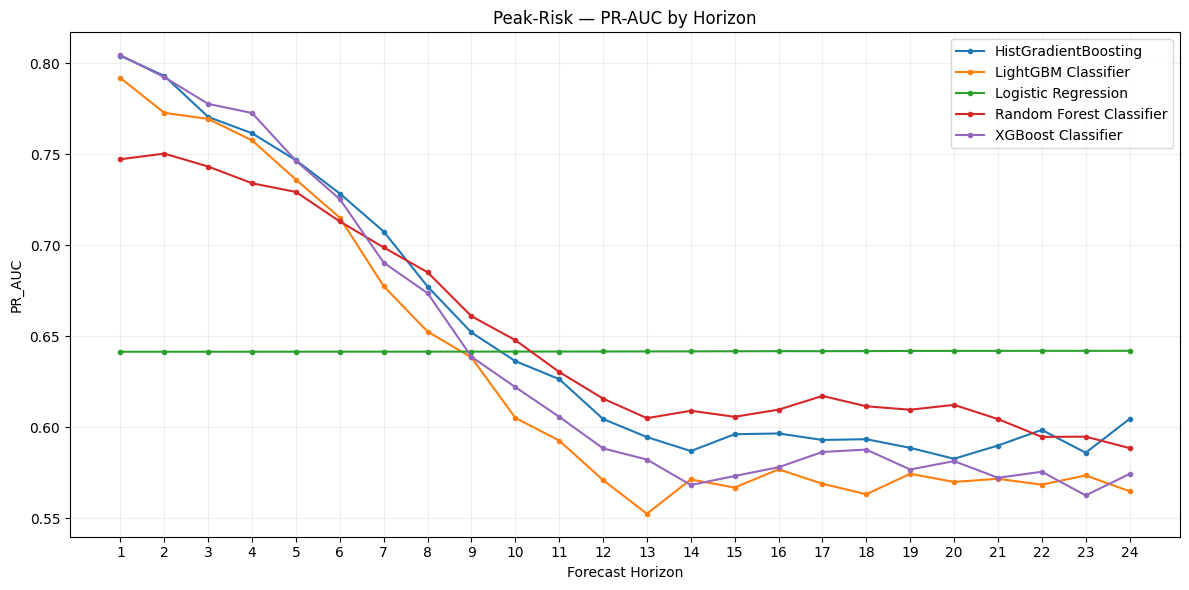

In [7]:
metric_by_horizon_plot(horizon_table, "pr_auc", "Peak-Risk — PR-AUC by Horizon"); plt.show()

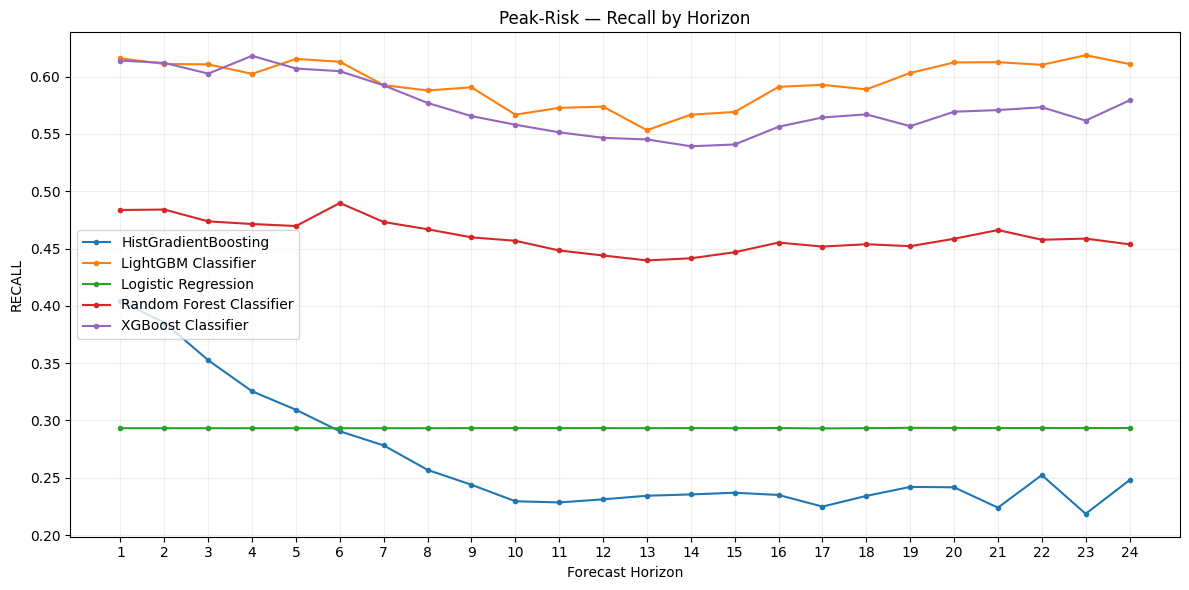

In [8]:
metric_by_horizon_plot(horizon_table, "recall", "Peak-Risk — Recall by Horizon"); plt.show()

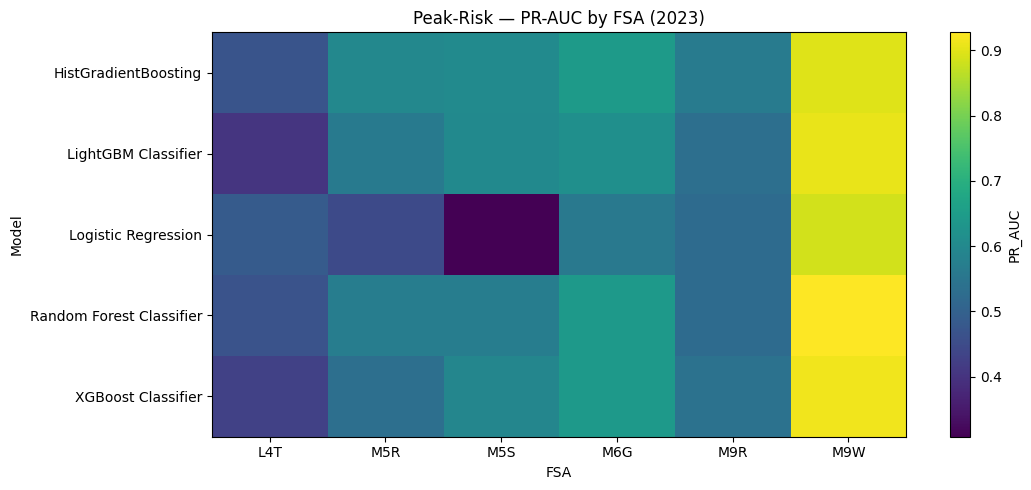

In [9]:
fsa_heatmap(fsa_table, "pr_auc", "fold_2023", "Peak-Risk — PR-AUC by FSA (2023)"); plt.show()

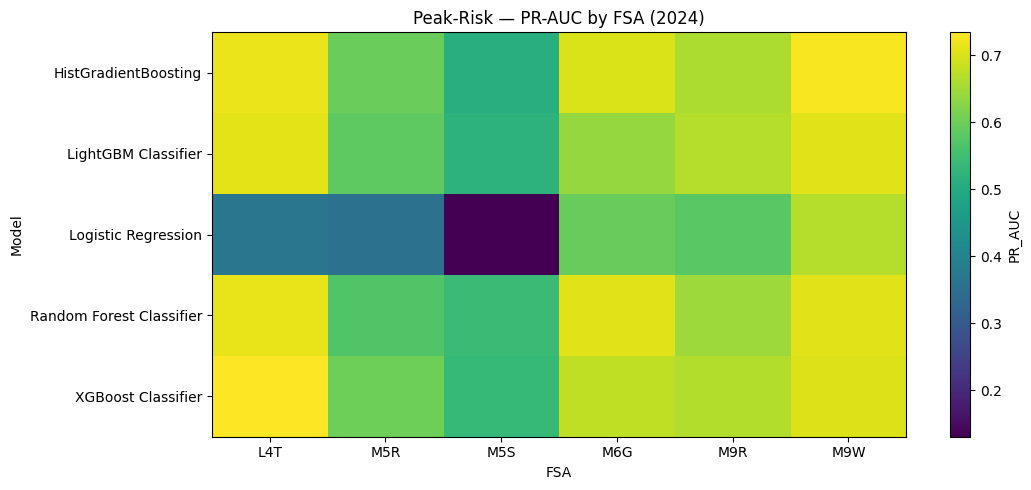

In [10]:
fsa_heatmap(fsa_table, "pr_auc", "fold_2024", "Peak-Risk — PR-AUC by FSA (2024)"); plt.show()